<a href="https://colab.research.google.com/github/innit-tomi/TelecomX_Latam-Challenge-3-/blob/main/Challenge%203%20Alura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Challenge 3

Parte 2 Telecom X, modelos de machine learning


## Importar Datos y transformacion


In [1]:
import pandas as pd


In [2]:
datos = pd.read_csv('/content/telecomX_limpio.csv')

In [3]:
datos.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   int64  
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


15 variables categoricas
5 variables numericas




In [6]:
df_encoded = pd.get_dummies(datos, columns=[
'gender',
'Partner',
'Dependents',
'PhoneService',
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaperlessBilling',
'PaymentMethod'
], drop_first=True)

In [7]:
df_encoded.shape

(7032, 31)

In [8]:
df_encoded.dtypes

,0
Churn,int64
SeniorCitizen,int64
tenure,int64
Charges.Monthly,float64
Charges.Total,float64
gender_Male,bool
Partner_Yes,bool
Dependents_Yes,bool
PhoneService_Yes,bool
MultipleLines_No phone service,bool


In [9]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [15]:
y.shape

(7032,)

In [16]:
y.value_counts()

,count
Churn,
0,5163
1,1869


##Propocion de Churn



In [25]:
y.value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


## Split de Datos

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
pip install imbalanced-learn

In [19]:
from imblearn.over_sampling import SMOTE

In [26]:
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [27]:


pd.Series(y_train).value_counts()

,count
Churn,
0,4130
1,1495


In [30]:


pd.Series(y_train_bal).value_counts()

,count
Churn,
0,4130
1,4130


## Correlacion de Variables y Graficos

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_churn = corr["Churn"].sort_values(ascending=False)

print(corr_churn)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
Charges.Monthly                          0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


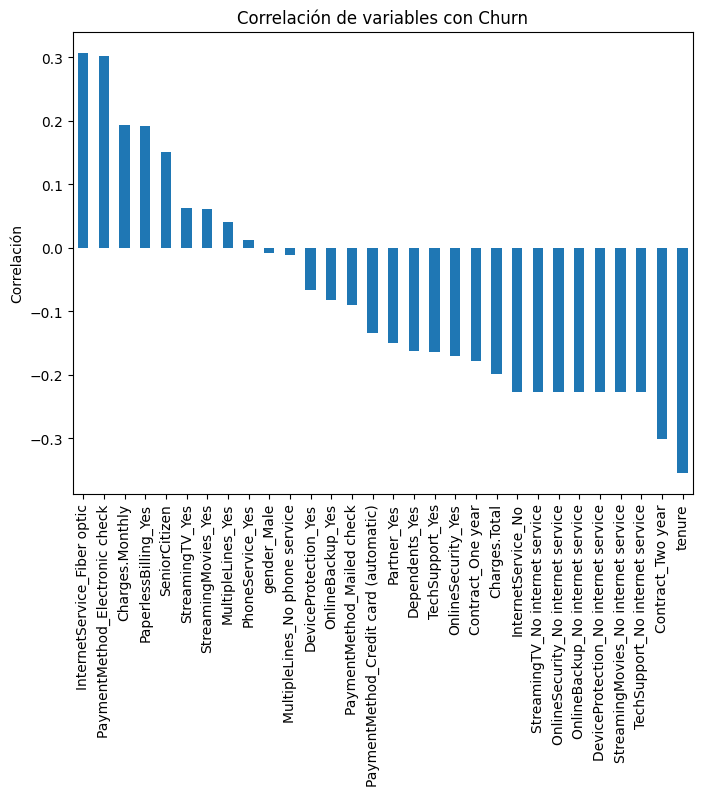

In [33]:
plt.figure(figsize=(8,6))
corr_churn.drop("Churn").plot(kind="bar")
plt.title("Correlación de variables con Churn")
plt.ylabel("Correlación")
plt.show()

La matriz de correlación indica que relacion tiene la variable objetivo(churn) con las siguientes


Variables que AUMENTAN el churn

fibra óptica

pagos electrónicos


Variables que REDUCEN el churn


tenure	clientes con más tiempo cancelan menos

Contract_Two year	contratos largos reducen churn

##Grafico Tiempo de contrato vs Cancelacion

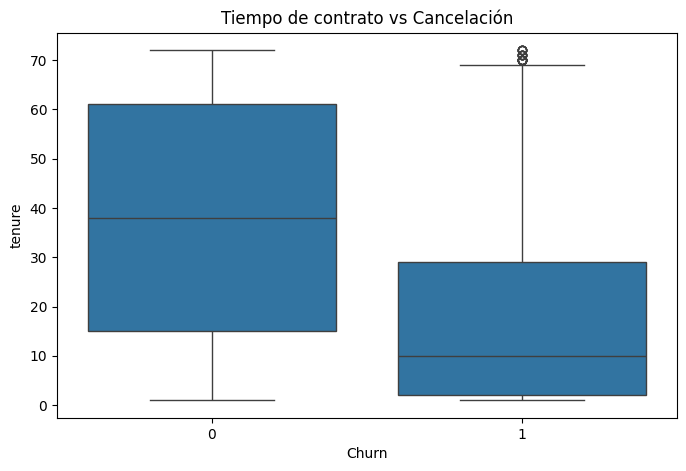

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=datos)
plt.title("Tiempo de contrato vs Cancelación")
plt.show()

##Grafico Gasto Total vs Cacelacion


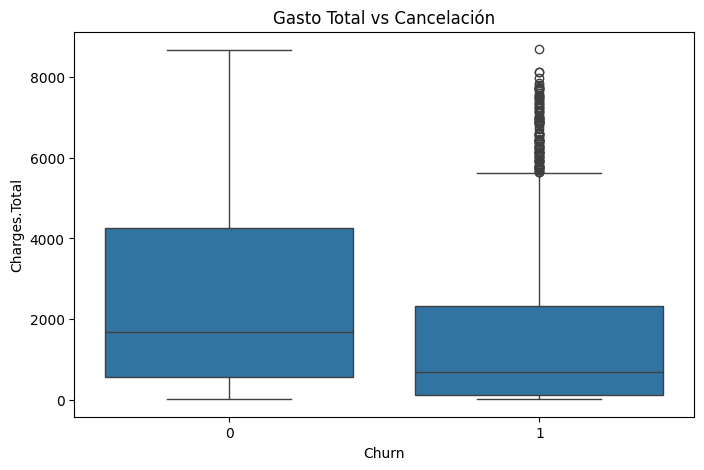

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Charges.Total', data=datos)
plt.title("Gasto Total vs Cancelación")
plt.show()

##Grafico Tipo de contrato vs Cancelacion

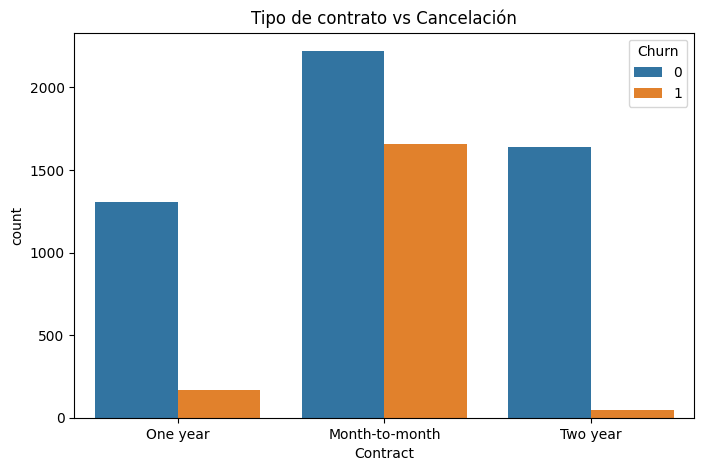

In [39]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=datos)
plt.title("Tipo de contrato vs Cancelación")
plt.show()

El análisis visual muestra que los clientes que cancelan presentan en promedio menor tiempo de permanencia en la empresa (tenure). Asimismo, el gasto total acumulado es significativamente menor en clientes que cancelan el servicio. Esto sugiere que la cancelación ocurre principalmente en las primeras etapas de la relación con el cliente. Además, los contratos mensuales presentan una mayor proporción de cancelaciones en comparación con contratos de largo plazo.

##Machine Learning

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

##Modelo Regresion Logistica

In [42]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train_bal)

LogisticRegression(max_iter=1000)

In [43]:
y_pred_log = log_model.predict(X_test_scaled)

##Rendimiento

In [44]:
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[872 161]
 [143 231]]
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.62      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.73      1407
weighted avg       0.79      0.78      0.79      1407



##Modelo RandomForest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_bal, y_train_bal)



RandomForestClassifier(random_state=42)

In [48]:
y_pred_rf = rf_model.predict(X_test)

##Rendimiento

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[881 152]
 [166 208]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1033
           1       0.58      0.56      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.77      0.77      1407



#Conclusion

**Objetivo del análisis**

El objetivo principal de este proyecto fue analizar los factores asociados a la cancelación de clientes **(churn)** en la empresa TelecomX y construir modelos predictivos capaces de identificar clientes con alta probabilidad de abandonar el servicio.

Comprender estos patrones permite a la empresa anticiparse a la cancelación, implementar estrategias de retención y mejorar la estabilidad de sus ingresos.



**Preparación y tratamiento de los datos**

El análisis comenzó con un proceso de limpieza y preparación del dataset, que incluyó:

Conversión de variables al tipo de dato correcto.

Eliminación de registros inconsistentes o vacíos.

Transformación de variables categóricas mediante One-Hot Encoding, permitiendo que los modelos de machine learning pudieran interpretarlas correctamente.

Separación de variables en features (X) y variable objetivo (y).

División del dataset en conjunto de entrenamiento y prueba para evaluar correctamente los modelos.

También se detectó un desbalance de clases, donde los clientes que no cancelaban eran significativamente más numerosos que los que sí cancelaban. Para abordar este problema se utilizó SMOTE, generando ejemplos sintéticos de la clase minoritaria y equilibrando el conjunto de entrenamiento.




**Análisis exploratorio e insights relevantes**

El análisis de correlación y visualización permitió identificar variables con fuerte relación con la cancelación de clientes.

**Factores asociados a mayor cancelación**

Las variables con mayor correlación positiva con churn fueron:

-InternetService_Fiber optic

-PaymentMethod_Electronic check

-Charges.Monthly

-PaperlessBilling

Esto sugiere que:

Clientes con internet de fibra óptica presentan mayor probabilidad de cancelar.

Los clientes que pagan mediante electronic check tienden a abandonar más el servicio.

Facturas mensuales más altas están asociadas con mayor churn.

Los clientes con facturación electrónica también presentan mayor cancelación.



**Factores asociados a menor cancelación**

Las variables con mayor correlación negativa con churn fueron:

-tenure (tiempo como cliente)

-Contract_Two year

-Contract_One year

-TechSupport

-OnlineSecurity

-Dependents

Esto indica que:

Cuanto más tiempo permanece un cliente en la empresa, menor es la probabilidad de cancelación.

Los contratos a largo plazo reducen significativamente el churn.

Servicios adicionales como soporte técnico o seguridad online aumentan la retención.




**Modelos predictivos desarrollados**

Se construyeron dos modelos de machine learning para predecir la cancelación de clientes:



Modelo 1 — Regresión Logística

Este modelo requiere normalización de variables, ya que su funcionamiento depende de la optimización de coeficientes.

Resultados:

Métrica	Valor
Accuracy	0.78
Precision	0.59
Recall	0.62
F1-score	0.60

La regresión logística mostró un buen equilibrio entre precisión y recall, logrando identificar correctamente una proporción relevante de clientes que cancelan.




Modelo 2 — Random Forest

Este modelo basado en árboles no requiere normalización, ya que divide los datos en función de reglas.

Resultados:

Métrica	Valor
Accuracy	0.77
Precision	0.58
Recall	0.56
F1-score	0.57

El modelo presentó un rendimiento ligeramente inferior al de la regresión logística.

El modelo de regresión logística obtuvo el mejor desempeño general, especialmente en recall, lo cual es importante en problemas de churn, ya que detectar clientes que podrían abandonar permite aplicar estrategias de retención.




**Conclusiones estratégicas**

El análisis permite extraer varias conclusiones importantes para la empresa:

Los clientes nuevos son los más propensos a cancelar, por lo que los primeros meses de servicio son críticos.

Los contratos a largo plazo reducen significativamente el churn, lo que sugiere que incentivar estos contratos podría mejorar la retención.

Clientes con facturas mensuales altas presentan mayor probabilidad de cancelación.

Servicios adicionales como soporte técnico y seguridad online parecen aumentar la permanencia de los clientes.

El método de pago electronic check está asociado a mayor cancelación, lo que podría indicar un perfil de cliente menos comprometido con el servicio.




**Recomendaciones**

Se sugieren las siguientes estrategias:

Incentivar contratos de mayor duración mediante descuentos o beneficios.

Mejorar la experiencia de clientes nuevos, especialmente durante los primeros meses.

Promover servicios adicionales que aumentan la permanencia del cliente.

Identificar clientes con facturas altas y ofrecer planes personalizados.

Utilizar el modelo predictivo desarrollado para detectar clientes con riesgo de churn y aplicar campañas de retención.